# Refinement Analysis: Understanding the Self-Refinement Process

This notebook analyzes the results from running refinement on 10 examples from the documents_train.csv dataset. We'll explore various aspects of the refinement process to understand how the system improves text quality over iterations.

##### TODO

* check example_015, original id: 2bbfadc4-a0dc-466f-9b20-1fddbe564437
* in what iteration did we get the best score
* mix model - run on examples 32 and 15 with claude as the task llm
* personalization

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [2]:
# Load the refinement results
csv_path = Path("../../r_50_5.csv")
df = pd.read_csv(csv_path)

print(f"📊 Loaded {len(df)} rows from {csv_path}")
print(f"📋 Columns: {list(df.columns)}")
print(f"\n🔍 Data shape: {df.shape}")
print(f"📝 Number of unique examples: {df['example_id'].nunique()}")
print(f"🔄 Maximum iterations per example: {df.groupby('example_id')['iteration_number'].max().max()}")

# Display first few rows
df.head()

📊 Loaded 210 rows from ../../r_50_5.csv
📋 Columns: ['example_id', 'original_id', 'title', 'profession', 'purpose', 'original_text_length', 'iteration_number', 'structure_score', 'coverage_score', 'focus_relevance_score', 'redundancy_score', 'combined_score', 'structure_reasoning', 'coverage_reasoning', 'focus_relevance_reasoning', 'redundancy_reasoning', 'combined_feedback', 'output', 'refinement_reasoning', 'is_final_iteration', 'converged_early', 'total_iterations', 'current_best_score', 'current_best_iteration']

🔍 Data shape: (210, 24)
📝 Number of unique examples: 50
🔄 Maximum iterations per example: 5


,example_id,original_id,title,profession,purpose,original_text_length,iteration_number,structure_score,coverage_score,focus_relevance_score,...,focus_relevance_reasoning,redundancy_reasoning,combined_feedback,output,refinement_reasoning,is_final_iteration,converged_early,total_iterations,current_best_score,current_best_iteration
0,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,1,0.85,1.00,1.00,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Add a one-line summary immediately after the...,# Text Entry on Smartwatches: Challenges and R...,"To address the feedback, I added a one-line su...",False,False,2,0.8875,1
1,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,2,1.00,1.00,1.00,...,The restructured text remains focused and rele...,The output text contains several instances of ...,NaN,# Smartwatch Text Entry Challenges and Researc...,NaN,True,True,2,0.9775,2
2,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,1,0.85,0.85,0.85,...,The restructured text maintains a focus on the...,The output text contains several instances of ...,- Add a one-line summary to concisely summariz...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I added a one-line su...",False,False,5,0.8125,1
3,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,2,0.85,0.85,0.95,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Fix the one-line summary to ensure it does n...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I made several change...",False,False,5,0.8500,2
4,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,3,0.85,1.00,1.00,...,The restructured text remains focused on the o...,"The output text contains some redundancy, part...",- Fix the one-line summary to ensure it does n...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I made the following ...",False,False,5,0.8875,3


## Step 1: Basic Statistics and Overview

Let's start by understanding the basic characteristics of our refinement data.

In [4]:
# Get basic statistics
final_iterations = df[df['is_final_iteration'] == True]

print("📈 BASIC STATISTICS")
print("=" * 50)
print(f"Total examples processed: {len(final_iterations)}")
print(f"Total iterations across all examples: {len(df)}")
print(f"Average iterations per example: {df.groupby('example_id')['iteration_number'].max().mean():.2f}")
print(f"Average final combined score: {final_iterations['combined_score'].mean():.3f}")
print(f"Standard deviation of final scores: {final_iterations['combined_score'].std():.3f}")
print(f"Range of final scores: {final_iterations['combined_score'].min():.3f} - {final_iterations['combined_score'].max():.3f}")

# Convergence statistics
converged_early = len(final_iterations[final_iterations['converged_early'] == True])
convergence_rate = converged_early / len(final_iterations)
print(f"\n🎯 CONVERGENCE STATISTICS")
print("=" * 50)
print(f"Examples that converged early: {converged_early}")
print(f"Convergence rate: {convergence_rate:.2%}")
print(f"Examples that reached max iterations: {len(final_iterations) - converged_early}")

📈 BASIC STATISTICS
Total examples processed: 50
Total iterations across all examples: 210
Average iterations per example: 4.20
Average final combined score: 0.930
Standard deviation of final scores: 0.074
Range of final scores: 0.675 - 1.000

🎯 CONVERGENCE STATISTICS
Examples that converged early: 22
Convergence rate: 44.00%
Examples that reached max iterations: 28


## Step 2: Score Trends Across Iterations

This is one of the most interesting aspects - how do scores improve over iterations?

In [6]:
avg_scores_by_iteration = df.groupby('iteration_number').agg({
    'combined_score': 'mean',
    'structure_score': 'mean',
    'coverage_score': 'mean',
    'focus_relevance_score': 'mean',
    'redundancy_score': 'mean'
}).reset_index()

print("📊 AVERAGE SCORES BY ITERATION")
print("=" * 50)
print(avg_scores_by_iteration.round(3))

📊 AVERAGE SCORES BY ITERATION
   iteration_number  combined_score  structure_score  coverage_score  \
0                 1           0.884            0.892           0.898   
1                 2           0.911            0.911           0.967   
2                 3           0.906            0.916           0.984   
3                 4           0.892            0.909           0.970   
4                 5           0.900            0.906           0.975   

   focus_relevance_score  redundancy_score  
0                  0.997             0.725  
1                  0.988             0.757  
2                  0.988             0.690  
3                  0.986             0.635  
4                  0.981             0.698  


📊 AVERAGE SCORES BY ITERATION
   iteration_number  combined_score  structure_score  coverage_score  \
0                 1           0.884            0.892           0.898   
1                 2           0.911            0.911           0.967   
2                 3           0.906            0.916           0.984   
3                 4           0.892            0.909           0.970   
4                 5           0.900            0.906           0.975   

   focus_relevance_score  redundancy_score  
0                  0.997             0.725  
1                  0.988             0.757  
2                  0.988             0.690  
3                  0.986             0.635  
4                  0.981             0.698  


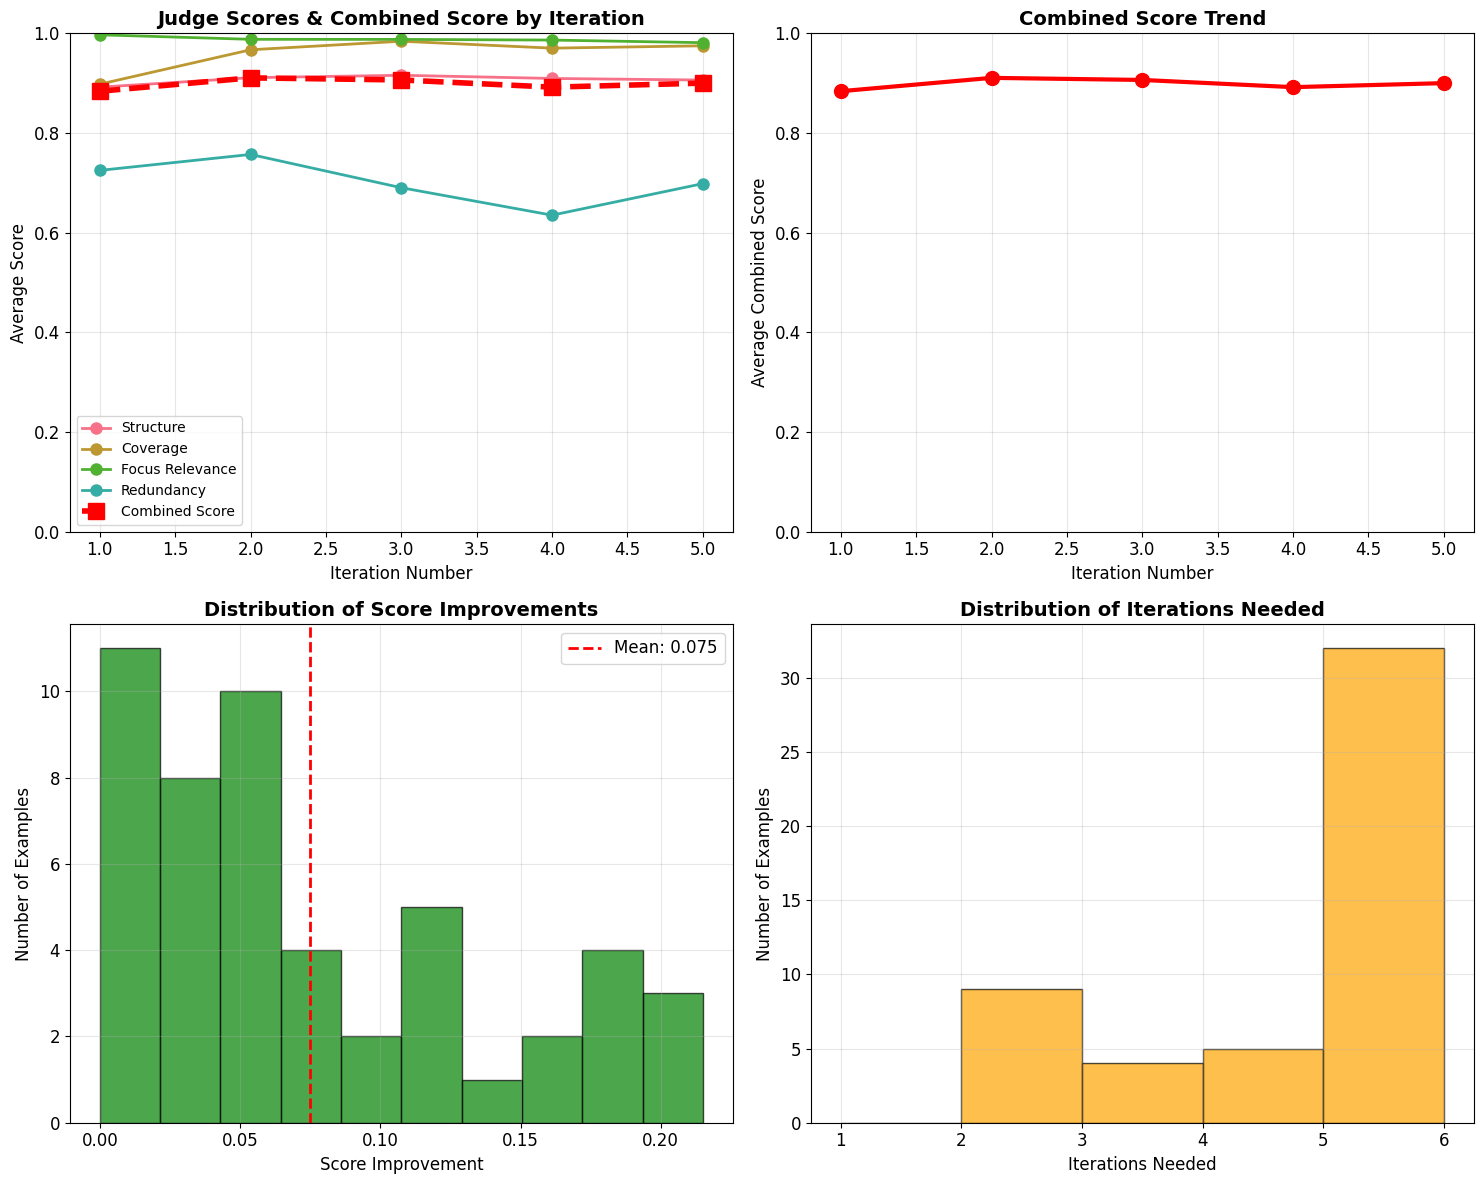


📈 IMPROVEMENT STATISTICS
Average improvement: 0.075
Median improvement: 0.054
Standard deviation of improvement: 0.063
Examples with positive improvement: 46/50
Examples with negative improvement: 0/50


In [9]:
# Calculate average scores by iteration
avg_scores_by_iteration = df.groupby('iteration_number').agg({
    'combined_score': 'mean',
    'structure_score': 'mean',
    'coverage_score': 'mean',
    'focus_relevance_score': 'mean',
    'redundancy_score': 'mean'
}).reset_index()

print("📊 AVERAGE SCORES BY ITERATION")
print("=" * 50)
print(avg_scores_by_iteration.round(3))


# Plot the trends
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: All judge scores + combined score
for score_col in ['structure_score', 'coverage_score', 'focus_relevance_score', 'redundancy_score']:
    ax1.plot(avg_scores_by_iteration['iteration_number'], 
             avg_scores_by_iteration[score_col], 
             marker='o', linewidth=2, markersize=8,
             label=score_col.replace('_score', '').replace('_', ' ').title())

# Add combined score with different style
ax1.plot(avg_scores_by_iteration['iteration_number'], 
         avg_scores_by_iteration['combined_score'], 
         marker='s', color='red', linewidth=4, markersize=12, linestyle='--',
         label='Combined Score')

ax1.set_xlabel('Iteration Number', fontsize=12)
ax1.set_ylabel('Average Score', fontsize=12)
ax1.set_title('Judge Scores & Combined Score by Iteration', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Plot 2: Combined score trend (you can remove this or use for something else)
ax2.plot(avg_scores_by_iteration['iteration_number'], 
         avg_scores_by_iteration['combined_score'], 
         marker='o', color='red', linewidth=3, markersize=10)
ax2.set_xlabel('Iteration Number', fontsize=12)
ax2.set_ylabel('Average Combined Score', fontsize=12)
ax2.set_title('Combined Score Trend', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# Plot 3: Score improvement from first to last iteration
first_scores = df[df['iteration_number'] == 1]['combined_score']
final_scores = final_iterations['current_best_score']
improvements = final_scores.values - first_scores.values

ax3.hist(improvements, bins=10, alpha=0.7, color='green', edgecolor='black')
ax3.set_xlabel('Score Improvement', fontsize=12)
ax3.set_ylabel('Number of Examples', fontsize=12)
ax3.set_title('Distribution of Score Improvements', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.axvline(improvements.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {improvements.mean():.3f}')
ax3.legend()

# Plot 4: Iterations needed distribution
iterations_needed = df.groupby('example_id')['iteration_number'].max()
ax4.hist(iterations_needed, bins=range(1, iterations_needed.max() + 2), 
         alpha=0.7, color='orange', edgecolor='black')
ax4.set_xlabel('Iterations Needed', fontsize=12)
ax4.set_ylabel('Number of Examples', fontsize=12)
ax4.set_title('Distribution of Iterations Needed', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print improvement statistics
print(f"\n📈 IMPROVEMENT STATISTICS")
print("=" * 50)
print(f"Average improvement: {improvements.mean():.3f}")
print(f"Median improvement: {np.median(improvements):.3f}")
print(f"Standard deviation of improvement: {improvements.std():.3f}")
print(f"Examples with positive improvement: {np.sum(improvements > 0)}/{len(improvements)}")
print(f"Examples with negative improvement: {np.sum(improvements < 0)}/{len(improvements)}")

## Step 3: Judge Performance Analysis

Which judges are most critical? Which ones are easiest to satisfy?

👨‍⚖️ JUDGE PERFORMANCE ANALYSIS
Focus Relevance: 0.989
Coverage: 0.956
Structure: 0.906
Redundancy: 0.706


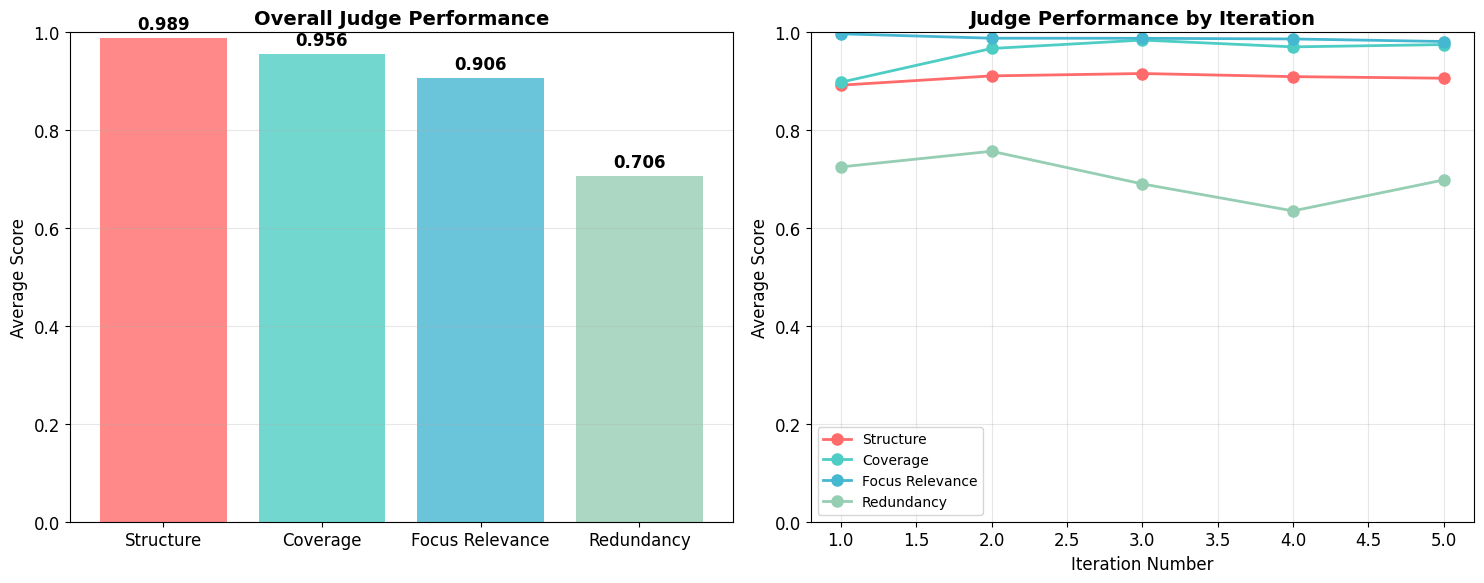


🎯 MOST CRITICAL JUDGE: Redundancy (Score: 0.706)
🎉 EASIEST JUDGE TO SATISFY: Focus Relevance (Score: 0.989)


In [10]:
# Analyze judge performance
judge_columns = ['structure_score', 'coverage_score', 'focus_relevance_score', 'redundancy_score']
judge_names = [col.replace('_score', '').replace('_', ' ').title() for col in judge_columns]

# Overall judge performance
judge_performance = df[judge_columns].mean().sort_values(ascending=False)

print("👨‍⚖️ JUDGE PERFORMANCE ANALYSIS")
print("=" * 50)
for judge, score in judge_performance.items():
    judge_name = judge.replace('_score', '').replace('_', ' ').title()
    print(f"{judge_name}: {score:.3f}")

# Plot judge performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Overall judge performance
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = ax1.bar(judge_names, judge_performance.values, color=colors, alpha=0.8)
ax1.set_ylabel('Average Score', fontsize=12)
ax1.set_title('Overall Judge Performance', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 1)

# Add value labels on bars
for bar, value in zip(bars, judge_performance.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Judge performance by iteration
for i, col in enumerate(judge_columns):
    ax2.plot(avg_scores_by_iteration['iteration_number'], 
             avg_scores_by_iteration[col], 
             marker='o', linewidth=2, markersize=8,
             label=judge_names[i], color=colors[i])

ax2.set_xlabel('Iteration Number', fontsize=12)
ax2.set_ylabel('Average Score', fontsize=12)
ax2.set_title('Judge Performance by Iteration', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Which judge is most critical (lowest average score)
most_critical_judge = judge_performance.idxmin()
most_critical_name = most_critical_judge.replace('_score', '').replace('_', ' ').title()
print(f"\n🎯 MOST CRITICAL JUDGE: {most_critical_name} (Score: {judge_performance.min():.3f})")

# Which judge is easiest to satisfy (highest average score)
easiest_judge = judge_performance.idxmax()
easiest_name = easiest_judge.replace('_score', '').replace('_', ' ').title()
print(f"🎉 EASIEST JUDGE TO SATISFY: {easiest_name} (Score: {judge_performance.max():.3f})")

## Step 4: Individual Example Analysis

Let's look at specific examples to understand the refinement process better.

🏆 TOP 3 PERFORMERS
1. INTRODUCTION...
   Score: 1.000, Iterations: 4

2. Answering the Research Question...
   Score: 1.000, Iterations: 5

3. The origins of the 1977 Additional Protocols...
   Score: 1.000, Iterations: 4

📉 BOTTOM 3 PERFORMERS
1. Fig. 1. Main structure of the review....
   Score: 0.780, Iterations: 5

2. Visual images help the reader read and understand texts...
   Score: 0.690, Iterations: 5

3. Arrival in Singapore...
   Score: 0.675, Iterations: 5



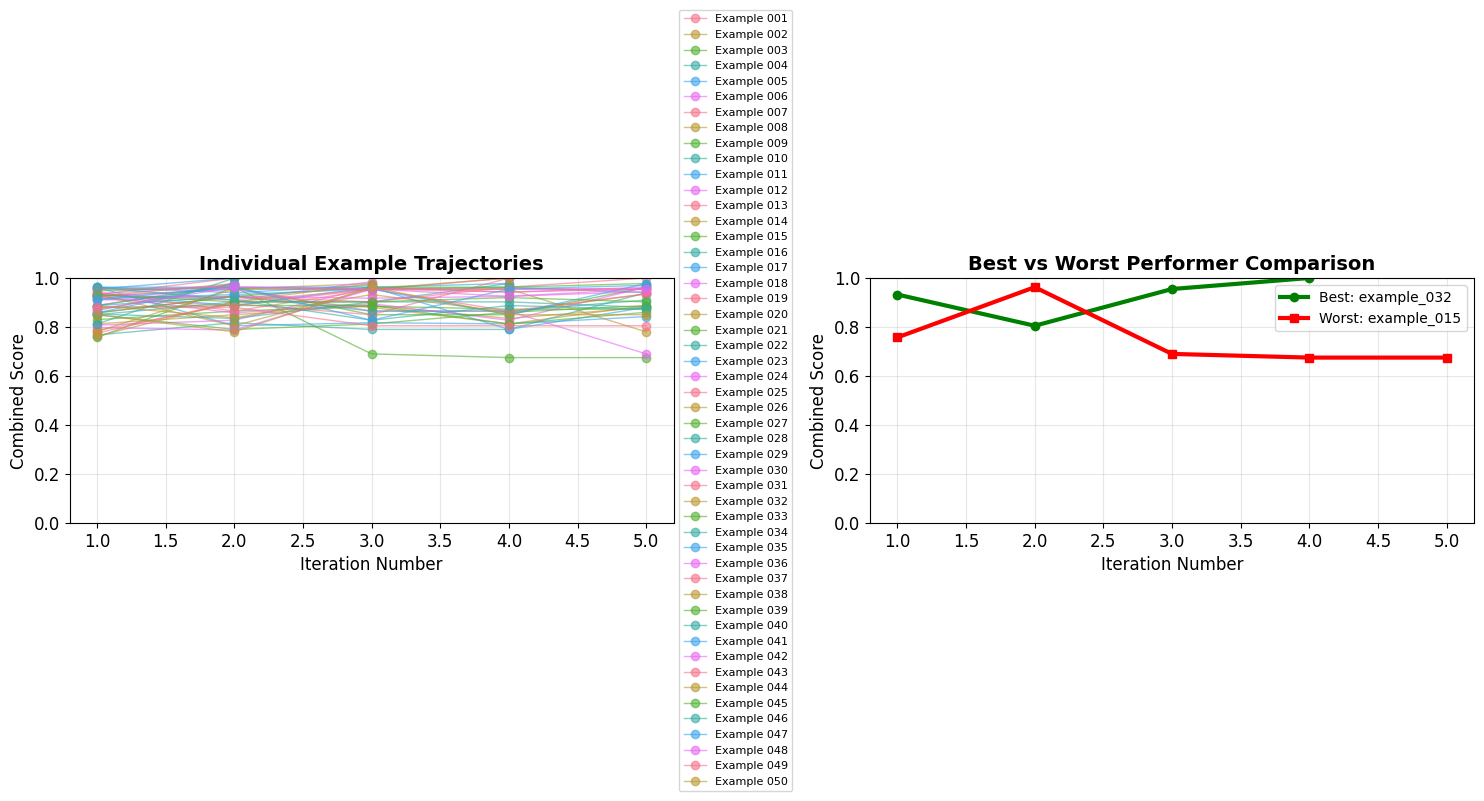

In [13]:
# Get top and bottom performers
final_scores_summary = final_iterations[['example_id', 'title', 'combined_score', 'total_iterations']].sort_values('combined_score', ascending=False)

print("🏆 TOP 3 PERFORMERS")
print("=" * 50)
for i, (_, row) in enumerate(final_scores_summary.head(3).iterrows(), 1):
    print(f"{i}. {row['title'][:60]}...")
    print(f"   Score: {row['combined_score']:.3f}, Iterations: {row['total_iterations']}")
    print()

print("📉 BOTTOM 3 PERFORMERS")
print("=" * 50)
for i, (_, row) in enumerate(final_scores_summary.tail(3).iterrows(), 1):
    print(f"{i}. {row['title'][:60]}...")
    print(f"   Score: {row['combined_score']:.3f}, Iterations: {row['total_iterations']}")
    print()

# Plot individual example trajectories
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: All example trajectories
for example_id in df['example_id'].unique():
    example_data = df[df['example_id'] == example_id].sort_values('iteration_number')
    ax1.plot(example_data['iteration_number'], example_data['combined_score'], 
             marker='o', alpha=0.6, linewidth=1)

ax1.set_xlabel('Iteration Number', fontsize=12)
ax1.set_ylabel('Combined Score', fontsize=12)
ax1.set_title('Individual Example Trajectories', fontsize=14, fontweight='bold')
ax1.legend([f'Example {example_id.split("_")[1]}' for example_id in df['example_id'].unique()], 
           loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Plot 2: Best vs Worst performer comparison
best_example = final_scores_summary.iloc[0]['example_id']
worst_example = final_scores_summary.iloc[-1]['example_id']

best_data = df[df['example_id'] == best_example].sort_values('iteration_number')
worst_data = df[df['example_id'] == worst_example].sort_values('iteration_number')

ax2.plot(best_data['iteration_number'], best_data['combined_score'], 
         marker='o', linewidth=3, label=f'Best: {best_example}', color='green')
ax2.plot(worst_data['iteration_number'], worst_data['combined_score'], 
         marker='s', linewidth=3, label=f'Worst: {worst_example}', color='red')

ax2.set_xlabel('Iteration Number', fontsize=12)
ax2.set_ylabel('Combined Score', fontsize=12)
ax2.set_title('Best vs Worst Performer Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Step 5: Convergence Analysis

How often does the system converge early? What patterns do we see?

🎯 CONVERGENCE ANALYSIS
Examples that converged early: 22
Examples that reached max iterations: 28
Convergence rate: 44.00%

📊 SCORE COMPARISON
Average score (converged early): 0.984
Average score (reached max): 0.888
Score difference: 0.095


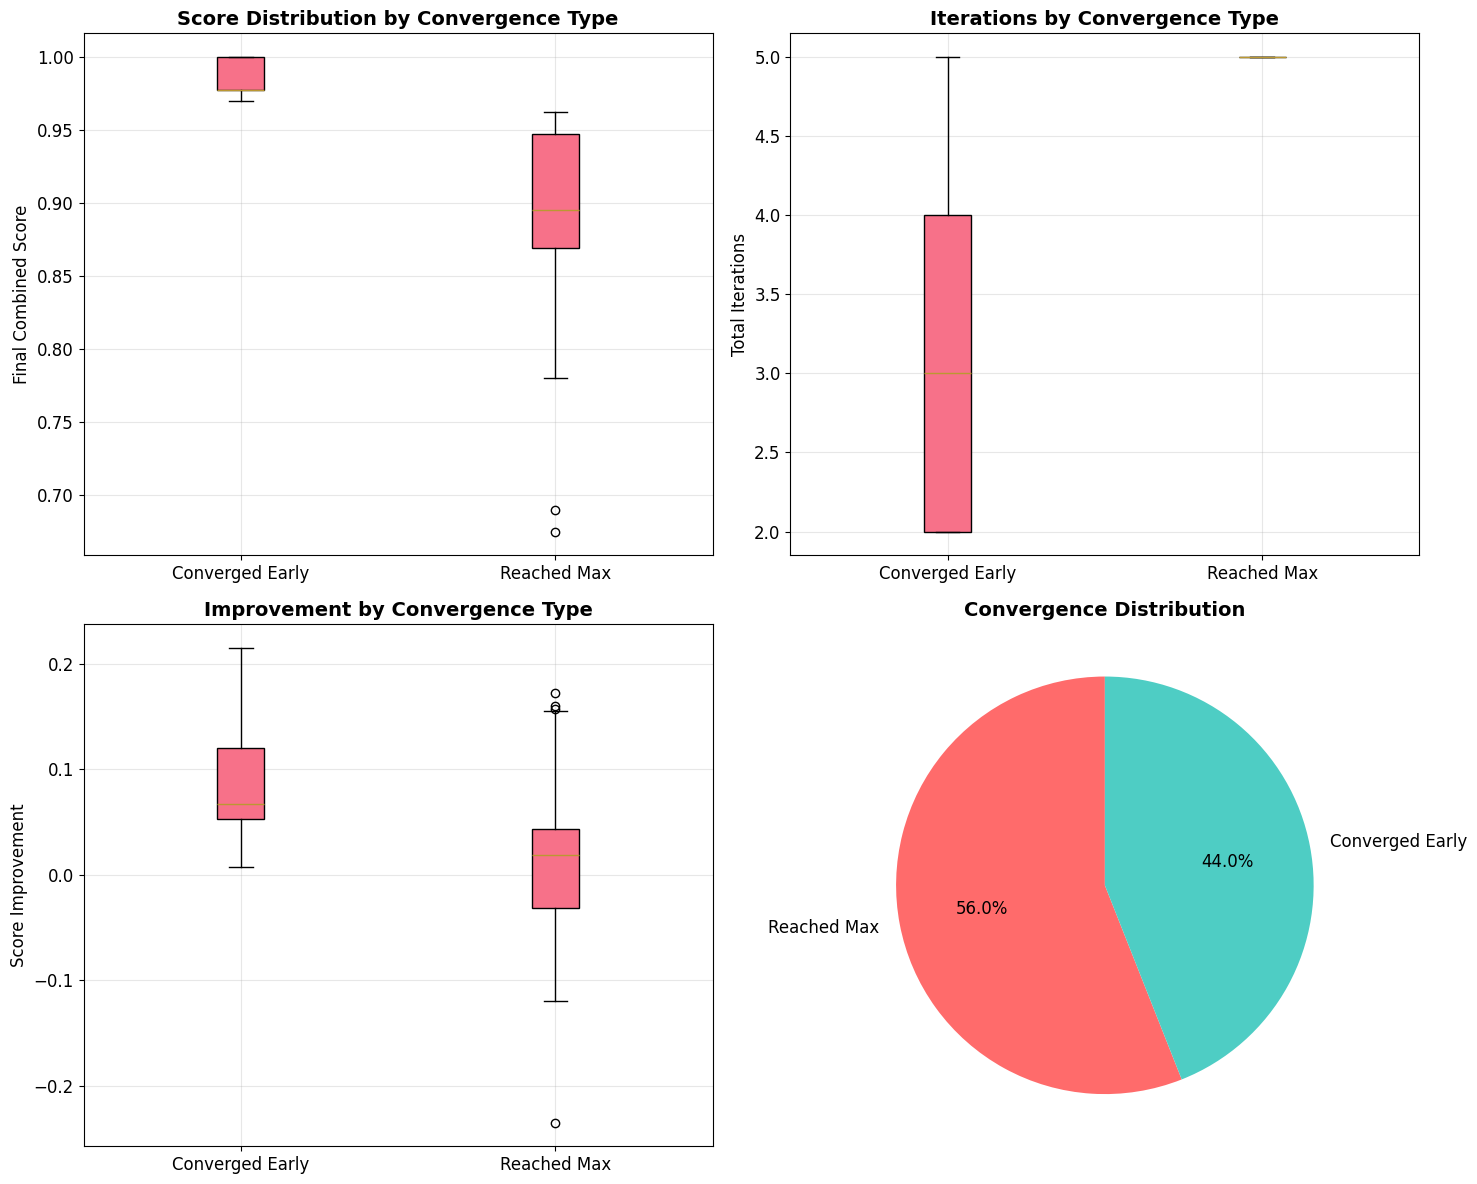

In [15]:
# Analyze convergence patterns
convergence_data = final_iterations[['example_id', 'converged_early', 'total_iterations', 'combined_score']]

print("🎯 CONVERGENCE ANALYSIS")
print("=" * 50)
print(f"Examples that converged early: {convergence_data['converged_early'].sum()}")
print(f"Examples that reached max iterations: {(~convergence_data['converged_early']).sum()}")
print(f"Convergence rate: {convergence_data['converged_early'].mean():.2%}")

# Compare scores between converged and non-converged examples
converged_scores = convergence_data[convergence_data['converged_early']]['combined_score']
non_converged_scores = convergence_data[~convergence_data['converged_early']]['combined_score']

print(f"\n📊 SCORE COMPARISON")
print(f"Average score (converged early): {converged_scores.mean():.3f}")
print(f"Average score (reached max): {non_converged_scores.mean():.3f}")
print(f"Score difference: {converged_scores.mean() - non_converged_scores.mean():.3f}")

# Plot convergence analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Convergence vs Non-convergence scores
ax1.boxplot([converged_scores, non_converged_scores], 
            labels=['Converged Early', 'Reached Max'], patch_artist=True)
ax1.set_ylabel('Final Combined Score', fontsize=12)
ax1.set_title('Score Distribution by Convergence Type', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Iterations needed by convergence type
converged_iterations = convergence_data[convergence_data['converged_early']]['total_iterations']
non_converged_iterations = convergence_data[~convergence_data['converged_early']]['total_iterations']

ax2.boxplot([converged_iterations, non_converged_iterations], 
            labels=['Converged Early', 'Reached Max'], patch_artist=True)
ax2.set_ylabel('Total Iterations', fontsize=12)
ax2.set_title('Iterations by Convergence Type', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Score improvement by convergence type
converged_improvements = []
non_converged_improvements = []

for example_id in convergence_data['example_id']:
    example_data = df[df['example_id'] == example_id]
    first_score = example_data[example_data['iteration_number'] == 1]['combined_score'].iloc[0]
    final_score = example_data[example_data['is_final_iteration'] == True]['combined_score'].iloc[0]
    improvement = final_score - first_score
    
    if convergence_data[convergence_data['example_id'] == example_id]['converged_early'].iloc[0]:
        converged_improvements.append(improvement)
    else:
        non_converged_improvements.append(improvement)

ax3.boxplot([converged_improvements, non_converged_improvements], 
            labels=['Converged Early', 'Reached Max'], patch_artist=True)
ax3.set_ylabel('Score Improvement', fontsize=12)
ax3.set_title('Improvement by Convergence Type', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Convergence rate pie chart
convergence_counts = convergence_data['converged_early'].value_counts()
ax4.pie(convergence_counts.values, labels=['Reached Max', 'Converged Early'], 
        autopct='%1.1f%%', startangle=90, colors=['#FF6B6B', '#4ECDC4'])
ax4.set_title('Convergence Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 6: Text Length Analysis

Does the length of the original text affect refinement performance?

📏 TEXT LENGTH ANALYSIS
Correlation between text length and final score: -0.156
Correlation between text length and iterations needed: -0.039

Text length statistics:
  Mean: 2002 characters
  Median: 1882 characters
  Min: 881 characters
  Max: 3922 characters


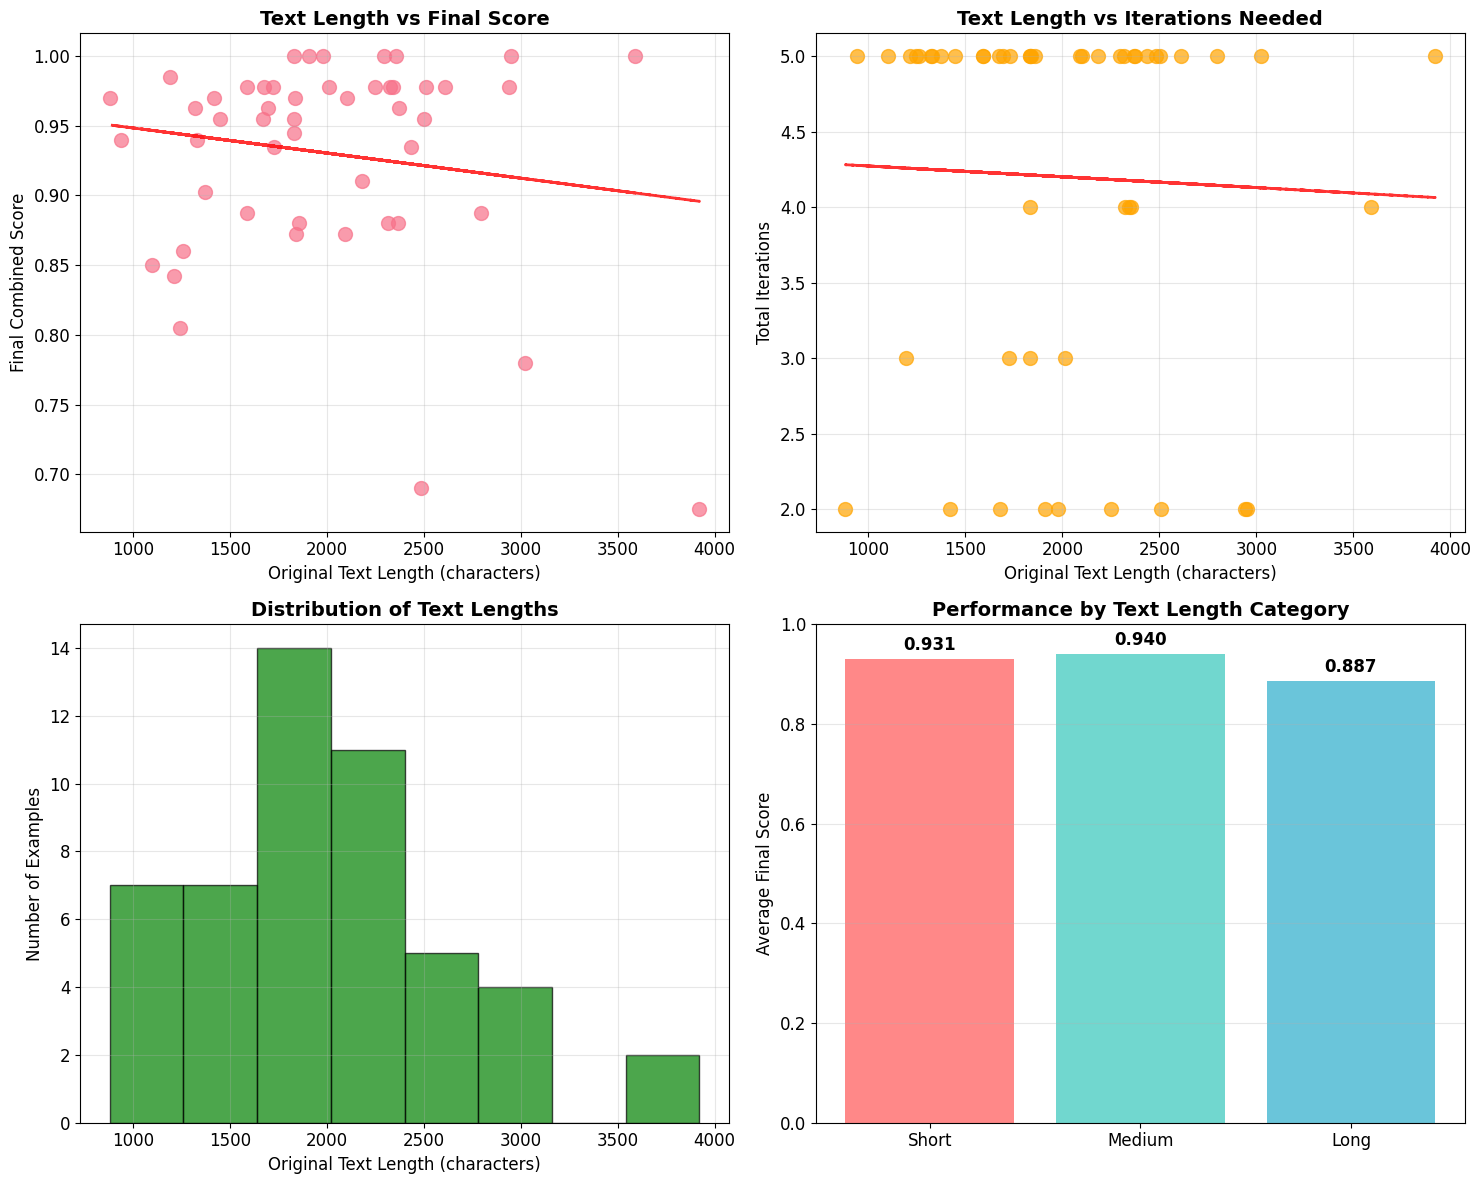

In [17]:
# Analyze relationship between text length and performance
length_performance = final_iterations[['example_id', 'original_text_length', 'combined_score', 'total_iterations']]

# Calculate correlations
length_score_corr = length_performance['original_text_length'].corr(length_performance['combined_score'])
length_iterations_corr = length_performance['original_text_length'].corr(length_performance['total_iterations'])

print("📏 TEXT LENGTH ANALYSIS")
print("=" * 50)
print(f"Correlation between text length and final score: {length_score_corr:.3f}")
print(f"Correlation between text length and iterations needed: {length_iterations_corr:.3f}")
print(f"\nText length statistics:")
print(f"  Mean: {length_performance['original_text_length'].mean():.0f} characters")
print(f"  Median: {length_performance['original_text_length'].median():.0f} characters")
print(f"  Min: {length_performance['original_text_length'].min():.0f} characters")
print(f"  Max: {length_performance['original_text_length'].max():.0f} characters")

# Plot length analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Text length vs final score
ax1.scatter(length_performance['original_text_length'], length_performance['combined_score'], 
            alpha=0.7, s=100)
ax1.set_xlabel('Original Text Length (characters)', fontsize=12)
ax1.set_ylabel('Final Combined Score', fontsize=12)
ax1.set_title('Text Length vs Final Score', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(length_performance['original_text_length'], length_performance['combined_score'], 1)
p = np.poly1d(z)
ax1.plot(length_performance['original_text_length'], p(length_performance['original_text_length']), 
         "r--", alpha=0.8, linewidth=2)

# Plot 2: Text length vs iterations needed
ax2.scatter(length_performance['original_text_length'], length_performance['total_iterations'], 
            alpha=0.7, s=100, color='orange')
ax2.set_xlabel('Original Text Length (characters)', fontsize=12)
ax2.set_ylabel('Total Iterations', fontsize=12)
ax2.set_title('Text Length vs Iterations Needed', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(length_performance['original_text_length'], length_performance['total_iterations'], 1)
p = np.poly1d(z)
ax2.plot(length_performance['original_text_length'], p(length_performance['original_text_length']), 
         "r--", alpha=0.8, linewidth=2)

# Plot 3: Text length distribution
ax3.hist(length_performance['original_text_length'], bins=8, alpha=0.7, color='green', edgecolor='black')
ax3.set_xlabel('Original Text Length (characters)', fontsize=12)
ax3.set_ylabel('Number of Examples', fontsize=12)
ax3.set_title('Distribution of Text Lengths', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Performance by text length category
length_performance['length_category'] = pd.cut(length_performance['original_text_length'], 
                                              bins=3, labels=['Short', 'Medium', 'Long'])
category_performance = length_performance.groupby('length_category')['combined_score'].mean()

bars = ax4.bar(category_performance.index, category_performance.values, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
ax4.set_ylabel('Average Final Score', fontsize=12)
ax4.set_title('Performance by Text Length Category', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 1)

# Add value labels
for bar, value in zip(bars, category_performance.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 7: Key Insights and Summary

Let's summarize the most interesting findings from our analysis.

In [19]:
print("🔍 KEY INSIGHTS FROM REFINEMENT ANALYSIS")
print("=" * 60)
print()

print("📈 SCORE IMPROVEMENT PATTERNS:")
print(f"  • Average improvement: {improvements.mean():.3f}")
print(f"  • {np.sum(improvements > 0)}/{len(improvements)} examples showed positive improvement")
print(f"  • {np.sum(improvements < 0)}/{len(improvements)} examples showed negative improvement")
print()

print("👨‍⚖️ JUDGE PERFORMANCE:")
print(f"  • Most critical judge: {most_critical_name} ({judge_performance.min():.3f})")
print(f"  • Easiest judge: {easiest_name} ({judge_performance.max():.3f})")
print(f"  • Judge score range: {judge_performance.max() - judge_performance.min():.3f}")
print()

print("🎯 CONVERGENCE BEHAVIOR:")
print(f"  • Convergence rate: {convergence_rate:.2%}")
print(f"  • Average iterations needed: {df.groupby('example_id')['iteration_number'].max().mean():.2f}")
print(f"  • Converged examples scored {converged_scores.mean() - non_converged_scores.mean():.3f} higher on average")
print()

print("📏 TEXT LENGTH EFFECTS:")
print(f"  • Text length vs score correlation: {length_score_corr:.3f}")
print(f"  • Text length vs iterations correlation: {length_iterations_corr:.3f}")
print()

print("🏆 PERFORMANCE RANGE:")
print(f"  • Best final score: {final_iterations['combined_score'].max():.3f}")
print(f"  • Worst final score: {final_iterations['combined_score'].min():.3f}")
print(f"  • Score range: {final_iterations['combined_score'].max() - final_iterations['combined_score'].min():.3f}")
print()

🔍 KEY INSIGHTS FROM REFINEMENT ANALYSIS

📈 SCORE IMPROVEMENT PATTERNS:
  • Average improvement: 0.075
  • 46/50 examples showed positive improvement
  • 0/50 examples showed negative improvement

👨‍⚖️ JUDGE PERFORMANCE:
  • Most critical judge: Redundancy (0.706)
  • Easiest judge: Focus Relevance (0.989)
  • Judge score range: 0.283

🎯 CONVERGENCE BEHAVIOR:
  • Convergence rate: 44.00%
  • Average iterations needed: 4.20
  • Converged examples scored 0.095 higher on average

📏 TEXT LENGTH EFFECTS:
  • Text length vs score correlation: -0.156
  • Text length vs iterations correlation: -0.039

🏆 PERFORMANCE RANGE:
  • Best final score: 1.000
  • Worst final score: 0.675
  • Score range: 0.325

